In [32]:
import pandas as pd
import requests

# 1. API Link (OpenFEMA)
API_LINK = 'https://www.fema.gov/api/open/v2/HousingAssistanceOwners?$metadata=off&$filter=state%20eq%20%27FL%27%20and%20county%20eq%20%27Miami-Dade%20(County)%27'

# 2. Access the Data
print("Fetching data from FEMA API...")
response = requests.get(API_LINK)

if response.status_code == 200:
    df = pd.DataFrame(response.json()['HousingAssistanceOwners' ])
    print(f"Data fetched successfully. Initial rows: {len(df)}")
else:
    print(f"Error fetching data: Status Code {response.status_code}")
    df = pd.DataFrame() # Create an empty DataFrame to prevent errors



Fetching data from FEMA API...
Data fetched successfully. Initial rows: 1000


In [2]:
df.head()

,disasterNumber,state,county,city,zipCode,validRegistrations,averageFemaInspectedDamage,totalInspected,totalDamage,noFemaInspectedDamage,...,approvedForFemaAssistance,totalApprovedIhpAmount,repairReplaceAmount,rentalAmount,otherNeedsAmount,approvedBetween1And10000,approvedBetween10001And25000,approvedBetween25001AndMax,totalMaxGrants,id
0,1460,FL,Miami-Dade (County),AVENTURA,33160,1,0.00,1,0.00,1,...,0,0.00,0.00,0.0,0.0,0,0,0,0,d19090b9-e95b-4faa-be50-b4b8ad0ba950
1,1460,FL,Miami-Dade (County),CAROL CITY,33055,2,215.70,1,431.40,0,...,1,431.40,431.40,0.0,0.0,1,0,0,0,b282cf01-b1a5-432a-8d64-3bb3d82586f3
2,1460,FL,Miami-Dade (County),CAROL CITY,33056,3,315.36,2,946.08,0,...,2,946.08,946.08,0.0,0.0,2,0,0,0,91ec676f-0514-41b4-a26e-b3b6c3eb9ed8
3,1460,FL,Miami-Dade (County),COCONUT GROVE,33133,1,0.00,1,0.00,1,...,0,0.00,0.00,0.0,0.0,0,0,0,0,a05ff90b-baf9-4f77-ba0e-55e82be69aeb
4,1460,FL,Miami-Dade (County),CORAL GABLES,33133,1,391.52,1,391.52,0,...,1,391.52,391.52,0.0,0.0,1,0,0,0,ba1f0f3e-dcad-4a60-86aa-b284e03929ec


In [4]:
# Filter for Florida ('FL')
df_filtered = df[df['state'] == 'FL']

# Filter for Miami-Dade County ('Miami-Dade (County)')
df_filtered = df_filtered[df_filtered['county'] == 'Miami-Dade (County)']




In [5]:
df_filtered.head()

,disasterNumber,state,county,city,zipCode,validRegistrations,averageFemaInspectedDamage,totalInspected,totalDamage,noFemaInspectedDamage,...,approvedForFemaAssistance,totalApprovedIhpAmount,repairReplaceAmount,rentalAmount,otherNeedsAmount,approvedBetween1And10000,approvedBetween10001And25000,approvedBetween25001AndMax,totalMaxGrants,id
0,1460,FL,Miami-Dade (County),AVENTURA,33160,1,0.00,1,0.00,1,...,0,0.00,0.00,0.0,0.0,0,0,0,0,d19090b9-e95b-4faa-be50-b4b8ad0ba950
1,1460,FL,Miami-Dade (County),CAROL CITY,33055,2,215.70,1,431.40,0,...,1,431.40,431.40,0.0,0.0,1,0,0,0,b282cf01-b1a5-432a-8d64-3bb3d82586f3
2,1460,FL,Miami-Dade (County),CAROL CITY,33056,3,315.36,2,946.08,0,...,2,946.08,946.08,0.0,0.0,2,0,0,0,91ec676f-0514-41b4-a26e-b3b6c3eb9ed8
3,1460,FL,Miami-Dade (County),COCONUT GROVE,33133,1,0.00,1,0.00,1,...,0,0.00,0.00,0.0,0.0,0,0,0,0,a05ff90b-baf9-4f77-ba0e-55e82be69aeb
4,1460,FL,Miami-Dade (County),CORAL GABLES,33133,1,391.52,1,391.52,0,...,1,391.52,391.52,0.0,0.0,1,0,0,0,ba1f0f3e-dcad-4a60-86aa-b284e03929ec


In [6]:
# inspect the data for null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   disasterNumber                           1000 non-null   int64  
 1   state                                    1000 non-null   object 
 2   county                                   1000 non-null   object 
 3   city                                     1000 non-null   object 
 4   zipCode                                  1000 non-null   object 
 5   validRegistrations                       1000 non-null   int64  
 6   averageFemaInspectedDamage               1000 non-null   float64
 7   totalInspected                           1000 non-null   int64  
 8   totalDamage                              1000 non-null   float64
 9   noFemaInspectedDamage                    1000 non-null   int64  
 10  femaInspectedDamageBetween1And10000      1000 non

In [7]:
# Keep only the column relevant to Location, Cost
relevant_columns = df[["zipCode", "disasterNumber", "totalDamage"]]
relevant_columns.head()


,zipCode,disasterNumber,totalDamage
0,33160,1460,0.00
1,33055,1460,431.40
2,33056,1460,946.08
3,33133,1460,0.00
4,33133,1460,391.52


In [30]:
#drop the missing values
df_clean = relevant_columns.dropna()


In [31]:
# Calculate Satistics
#count the number of rows
df_clean.count()


,0
zipCode,1000
disasterNumber,1000
totalDamage,1000


In [10]:
# average damage
float(df_clean["totalDamage"].mean())


188261.54807999998

In [12]:
# maximum damage
df_clean['totalDamage'].max()



5537522.13


    
    The final number of rows: 10000
    Average damage cost: $188261.55
    maximum demage cost: $5537522.13








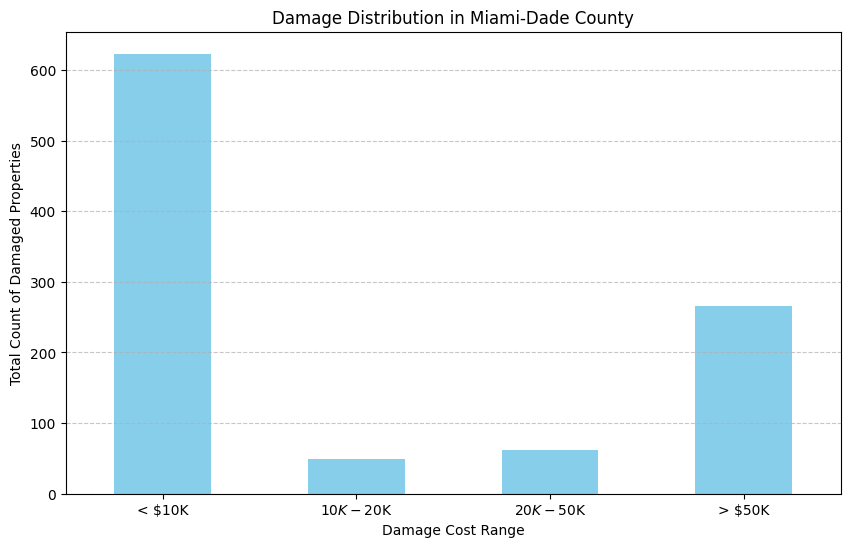

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Plot 1: Damage Distribution (Histogram)
# Define bins for the histogram
bins = [0, 10000, 20000, 50000, np.inf] # Use np.inf for the upper bound of the last bin
labels = ['< $10K', '$10K - $20K', '$20K - $50K', '> $50K']

# Create a categorical series for the bins
df_clean['damage_bin'] = pd.cut(df_clean['totalDamage'], bins=bins, labels=labels, right=False)

# Count the occurrences in each bin
damage_counts = df_clean['damage_bin'].value_counts().sort_index()

# Create the plot
plt.figure(figsize=(10, 6))
damage_counts.plot(kind='bar', color='skyblue')
plt.title('Damage Distribution in Miami-Dade County')
plt.xlabel('Damage Cost Range')
plt.ylabel('Total Count of Damaged Properties')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

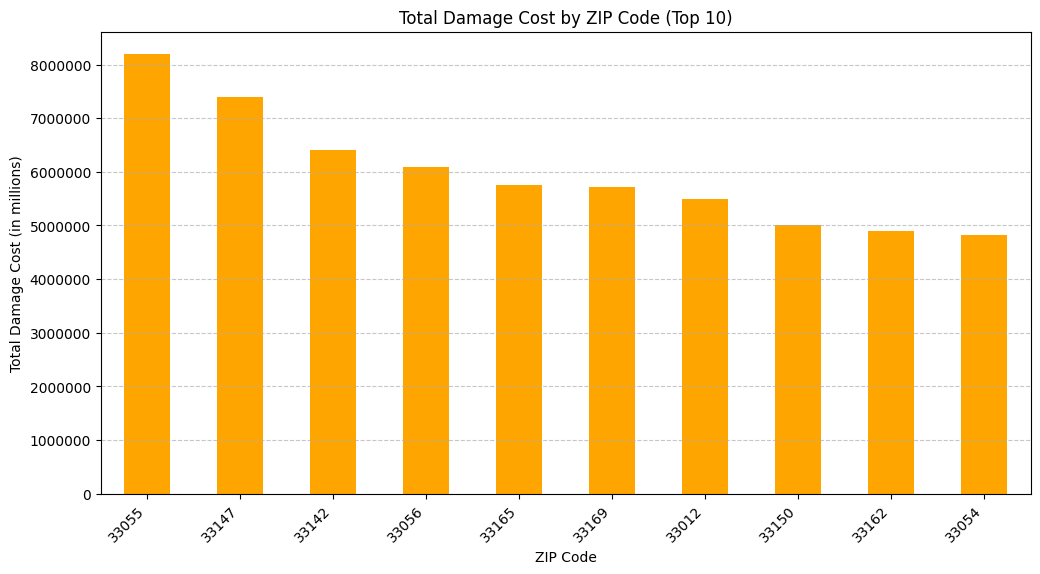

In [29]:
# Plot 2: Location Pattern (Bar Chart of Total Damage by ZIP Code)

# Calculate total damage per ZIP code
zip_damage = df_clean.groupby('zipCode')['totalDamage'].sum().sort_values(ascending=False)

# Select the top N ZIP codes for a cleaner visualization
zip_damage_top = zip_damage.head(10)

# Create the bar chart
plt.figure(figsize=(12, 6))
zip_damage_top.plot(kind='bar', color='orange')
plt.title('Total Damage Cost by ZIP Code (Top 10)')
plt.xlabel('ZIP Code')
plt.ylabel('Total Damage Cost (in millions)')
plt.ticklabel_format(style='plain', axis='y'). #This will prevent y values from using scientific notation
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
df_clean.to_csv("SwikritiKc.csv", index = False)